In [39]:
from IndividualParcellation.global_config import *
import pickle
import numpy as np
import pandas as pd
import torch as pt
import nitools as nt
import seaborn as sns
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
import nilearn.plotting as plotting
from Functional_Fusion.dataset import DataSetMDTB
from Functional_Fusion.dataset import DataSetLanguage
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.evaluation as ev
from DCBC.utilities import compute_dist
from IndividualParcellation.evaluate import calc_test_dcbc
from MultiTaskBattery.MultiTaskBattery.optimal_battery import find_optimal_battery
from PcmPy.util import est_G_crossval
import os


# Constants

For this analysis , I will use a mask that includes D + S regions

In [40]:
# Define ROIs to be used for the analysis
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'

ROI_cerebellum=['S1L', 'S1R', 'S2L', 'S2R', 'S3L', 'S3R', 'S4L', 'S4R','D1L', 'D1R', 'D2L', 'D2R', 'D3L', 'D3R', 'D4L', 'D4R']
ROI_cortex = [6,7] # only used if space is fs32k
space = 'SUIT3'
atlas, _ = am.get_atlas(space)

In [41]:
# Check if CUDA is available
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Step 1: Load group parcellations for ROI specific analysis

In [44]:
if space == 'fs32k':
    atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
    model_name_L = f'{atlas_dir}/yeo7.L.label.gii'
    model_name_R = f'{atlas_dir}/yeo7.R.label.gii'

    yeo_parcels = atlas.read_data([model_name_L,model_name_R])
    ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)

elif space == 'SUIT3':
    atlas_dir = f'{base_dir}/Atlases/tpl-SUIT'
    model_name = f'/atl-NettekovenSym32_space-SUIT_dseg.nii'
    U = atlas.read_data(atlas_dir + model_name)
    U = U.T
    _, cmap, labels = nt.read_lut(f'{atlas_dir}/atl-NettekovenSym32.lut')
    ROI_mask = np.zeros_like(U)
    for i, label in enumerate(labels):
        if label in ROI_cerebellum:
            ROI_mask[U == i] = 1

else:
    print('atlas space not supported')

# Sanity check: Plot ROI

In [45]:
# if space == 'fs32k':
#     surfs = [base_dir+ "/Atlases" + f'/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii' for i, h in enumerate(['L', 'R'])]
#     mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

#     # Convert to CIFTI format
#     cifti = atlas.data_to_cifti(mask_reshaped)

#     # Extract the data for the cortical surfaces
#     all_img = nt.surf_from_cifti(cifti)

#     # Plot cortical maps for left and right hemispheres
#     fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 6))
#     for h, hemi in enumerate(['left', 'right']):
#         plotting.plot_surf_stat_map(
#             surfs[h], all_img[h], hemi=hemi,
#             colorbar=False,
#             cmap='binary',
#             axes=axes[h],
#             threshold = 0.1,
#             title=f"{ROI_cortex} - {hemi.capitalize()} Hemisphere")

# elif space =='SUIT3':
#     lang_img = atlas.data_to_nifti(ROI_mask)
#     surface = flatmap.vol_to_surf(lang_img, space='SUIT',stats = 'mode')
#     flatmap.plot(data=surface, new_figure=True, colorbar=True, render='matplotlib')

# else:
#     print('not supported')

# Step 2a: Load datasets for search algorithm

Here I'm using MDTB-s1 for search algorithm

In [47]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

# Step 2b: Apply mask to data

In [48]:
task_matrix = data_mdtb_s1 
task_matrix = data_mdtb_s1 * ROI_mask
task_names = info_mdtb_1.cond_name.values

# Step 3: Run search algorithm

Run search algorithm on averaged group data

In [36]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=6, 
    function='trace', 
    top_n=10, 
    sample_size=None,
    average_across_subjects=False
)

variance_combinations = []

# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_mdtb_1.cond_name.values[index] for index in comb]
    variance_combinations.append(combo_task_names)
    print(f'Combination {i}:', combo_task_names)
    


Processing sample 1/1344904
Processing sample 100001/1344904
Processing sample 200001/1344904
Processing sample 300001/1344904
Processing sample 400001/1344904
Processing sample 500001/1344904
Processing sample 600001/1344904
Processing sample 700001/1344904
Processing sample 800001/1344904
Processing sample 900001/1344904
Processing sample 1000001/1344904
Processing sample 1100001/1344904
Processing sample 1200001/1344904
Processing sample 1300001/1344904
Combination 1: ['ToM', 'UnpleasantScenes', 'MotorImagery', 'FingerSeq', 'Verbal2Back', 'VerbGen']
Combination 2: ['ToM', 'ToM', 'MotorImagery', 'FingerSeq', 'Verbal2Back', 'VerbGen']
Combination 3: ['ToM', 'ToM', 'VideoAct', 'MotorImagery', 'Verbal2Back', 'VerbGen']
Combination 4: ['ToM', 'UnpleasantScenes', 'MotorImagery', 'Verbal2Back', 'Verbal2Back', 'VerbGen']
Combination 5: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Verbal2Back', 'SpatialNavigation', 'VerbGen']
Combination 6: ['ToM', 'ToM', 'VideoAct', 'MotorImagery', 'Verbal2Bac

In [29]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=6, 
    function='inverse_trace', 
    top_n=10, 
    sample_size=None,
    average_across_subjects=False,offset= 0.1
)
inverse_combinations_big = []
# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_mdtb_1.cond_name.values[index] for index in comb]
    inverse_combinations_big.append(combo_task_names)
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/1344904
Processing sample 100001/1344904
Processing sample 200001/1344904
Processing sample 300001/1344904
Processing sample 400001/1344904
Processing sample 500001/1344904
Processing sample 600001/1344904
Processing sample 700001/1344904
Processing sample 800001/1344904
Processing sample 900001/1344904
Processing sample 1000001/1344904
Processing sample 1100001/1344904
Processing sample 1200001/1344904
Processing sample 1300001/1344904
Combination 1: ['ToM', 'UnpleasantScenes', 'MotorImagery', 'FingerSeq', 'Verbal2Back', 'VerbGen']
Combination 2: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Verbal2Back', 'SpatialNavigation', 'VerbGen']
Combination 3: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Verbal2Back', 'VerbGen', 'rest']
Combination 4: ['ToM', 'HappyFaces', 'MotorImagery', 'FingerSeq', 'Verbal2Back', 'VerbGen']
Combination 5: ['ToM', 'VideoAct', 'UnpleasantScenes', 'FingerSeq', 'Verbal2Back', 'VerbGen']
Combination 6: ['ToM', 'SadFaces', 'MotorImagery', 'FingerSeq'

In [13]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=6, 
    function='inverse_trace', 
    top_n=10, 
    sample_size=None,
    average_across_subjects=False,offset= 0.00001
)
inverse_combinations_small = []
# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_mdtb_1.cond_name.values[index] for index in comb]
    inverse_combinations_small.append(combo_task_names)
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/1344904
Processing sample 100001/1344904
Processing sample 200001/1344904
Processing sample 300001/1344904
Processing sample 400001/1344904
Processing sample 500001/1344904
Processing sample 600001/1344904
Processing sample 700001/1344904
Processing sample 800001/1344904
Processing sample 900001/1344904
Processing sample 1000001/1344904
Processing sample 1100001/1344904
Processing sample 1200001/1344904
Processing sample 1300001/1344904
Combination 1: ['VideoAct', 'UnpleasantScenes', 'DigitJudgement', 'HappyFaces', 'StroopIncon', 'StroopCon']
Combination 2: ['UnpleasantScenes', 'PleasantScenes', 'HappyFaces', 'StroopIncon', 'VisualSearchSmall', 'VisualSearchLarge']
Combination 3: ['PleasantScenes', 'SadFaces', 'HappyFaces', 'IntervalTiming', 'VisualSearchSmall', 'VisualSearchMed']
Combination 4: ['PleasantScenes', 'DigitJudgement', 'HappyFaces', 'Verbal0Back', 'VisualSearchSmall', 'VisualSearchLarge']
Combination 5: ['UnpleasantScenes', 'PleasantScenes', 'CheckerBoa

In [37]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=6, 
    function='determinant', 
    top_n=10, 
    sample_size=None,
    average_across_subjects=False
)

determinant_combinations = []
# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_mdtb_1.cond_name.values[index] for index in comb]
    determinant_combinations.append(combo_task_names)
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/1344904
Processing sample 100001/1344904
Processing sample 200001/1344904
Processing sample 300001/1344904
Processing sample 400001/1344904
Processing sample 500001/1344904
Processing sample 600001/1344904
Processing sample 700001/1344904
Processing sample 800001/1344904
Processing sample 900001/1344904
Processing sample 1000001/1344904
Processing sample 1100001/1344904
Processing sample 1200001/1344904
Processing sample 1300001/1344904
Combination 1: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Object0Back', 'VerbGen', 'rest']
Combination 2: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Object0Back', 'SpatialNavigation', 'VerbGen']
Combination 3: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Verbal2Back', 'SpatialNavigation', 'VerbGen']
Combination 4: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Verbal2Back', 'VerbGen', 'rest']
Combination 5: ['ToM', 'UnpleasantScenes', 'MotorImagery', 'FingerSeq', 'Object0Back', 'VerbGen']
Combination 6: ['ToM', 'HappyFaces', 'FingerSeq', 'Verb

In [11]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=6, 
    function='maximize_lowest_eigenvalue', 
    top_n=10, 
    sample_size=None,
    average_across_subjects=False
)

determinant_combinations = []
# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [info_mdtb_1.cond_name.values[index] for index in comb]
    determinant_combinations.append(combo_task_names)
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/1344904
Processing sample 100001/1344904
Processing sample 200001/1344904
Processing sample 300001/1344904
Processing sample 400001/1344904
Processing sample 500001/1344904
Processing sample 600001/1344904
Processing sample 700001/1344904
Processing sample 800001/1344904
Processing sample 900001/1344904
Processing sample 1000001/1344904
Processing sample 1100001/1344904
Processing sample 1200001/1344904
Processing sample 1300001/1344904
Combination 1: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Verbal0Back', 'VerbGen', 'rest']
Combination 2: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Object0Back', 'SpatialNavigation', 'VerbGen']
Combination 3: ['ToM', 'VideoAct', 'DigitJudgement', 'FingerSeq', 'Object0Back', 'VerbGen']
Combination 4: ['NoGo', 'VideoKnots', 'FingerSeq', 'Object0Back', 'SpatialNavigation', 'VerbGen']
Combination 5: ['ToM', 'UnpleasantScenes', 'FingerSeq', 'Object0Back', 'VerbGen', 'rest']
Combination 6: ['ToM', 'VideoAct', 'FingerSeq', 'Object0Back', 'Ve

# Step 4a: Evaluate using DCBC

loading data again, here mdtb-s1 is used for fitting emission models for the task batteries

mdtb-s2 will be used for the evaluation

In [14]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1 = data_mdtb_s1 * ROI_mask

In [15]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s2,info_mdtb_2  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondRun')
data_mdtb_s2 = data_mdtb_s2 * ROI_mask

In [16]:
dist = compute_dist(atlas.world.T, resolution=1)
ROI_mask_tensor = pt.tensor(ROI_mask, dtype=pt.bool)
masked_dist = dist[ROI_mask_tensor][:, ROI_mask_tensor]


Load group parcellations. These are just fullmodels, that have trained arrangament models. The arrangement models were trained on MDTB-s1 + language localizer (ses-01), initialized with different Ks

In [17]:
# variance_combinations = [['ToM',
#   'ToM',
#   'UnpleasantScenes',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'VideoAct',
#   'UnpleasantScenes',
#   'MotorImagery',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'VideoAct',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'UnpleasantScenes',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'Object0Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'VideoAct',
#   'UnpleasantScenes',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'HappyFaces',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'SadFaces',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'VideoAct',
#   'UnpleasantScenes',
#   'FingerSeq',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'VideoAct',
#   'HappyFaces',
#   'MotorImagery',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'ToM',
#   'VideoAct',
#   'SadFaces',
#   'MotorImagery',
#   'Verbal2Back',
#   'Verbal2Back',
#   'VerbGen']]

# inverse_combinations = [['Go',
#   'ToM',
#   'PleasantScenes',
#   'HappyFaces',
#   'IntervalTiming',
#   'MotorImagery',
#   'SpatialNavigation',
#   'VisualSearchMed'],
#  ['ToM',
#   'ToM',
#   'UnpleasantScenes',
#   'PleasantScenes',
#   'Math',
#   'Math',
#   'HappyFaces',
#   'VisualSearchLarge'],
#  ['UnpleasantScenes',
#   'SadFaces',
#   'IntervalTiming',
#   'MotorImagery',
#   'FingerSimple',
#   'Object0Back',
#   'rest',
#   'rest'],
#  ['VideoKnots',
#   'UnpleasantScenes',
#   'Math',
#   'CheckerBoard',
#   'SadFaces',
#   'FingerSimple',
#   'VerbGen',
#   'rest'],
#  ['PleasantScenes',
#   'SadFaces',
#   'SadFaces',
#   'SadFaces',
#   'HappyFaces',
#   'IntervalTiming',
#   'IntervalTiming',
#   'VisualSearchSmall'],
#  ['NoGo',
#   'PleasantScenes',
#   'Math',
#   'Math',
#   'HappyFaces',
#   'MotorImagery',
#   'FingerSeq',
#   'VisualSearchLarge'],
#  ['ToM',
#   'ToM',
#   'UnpleasantScenes',
#   'DigitJudgement',
#   'SadFaces',
#   'FingerSeq',
#   'Object2Back',
#   'WordRead'],
#  ['PleasantScenes',
#   'Math',
#   'Math',
#   'HappyFaces',
#   'IntervalTiming',
#   'Object2Back',
#   'SpatialNavigation',
#   'VerbGen'],
#  ['UnpleasantScenes',
#   'SadFaces',
#   'FingerSimple',
#   'FingerSimple',
#   'Object0Back',
#   'Object0Back',
#   'Object2Back',
#   'StroopCon'],
#  ['UnpleasantScenes',
#   'Math',
#   'Math',
#   'Math',
#   'Math',
#   'SadFaces',
#   'VerbGen',
#   'VisualSearchSmall']]

# determinant_combinations = [['ToM',
#   'VideoAct',
#   'VideoKnots',
#   'UnpleasantScenes',
#   'FingerSeq',
#   'Verbal2Back',
#   'SpatialNavigation',
#   'VerbGen'],
#  ['ToM',
#   'VideoAct',
#   'VideoKnots',
#   'UnpleasantScenes',
#   'FingerSeq',
#   'Object0Back',
#   'SpatialNavigation',
#   'VerbGen'],
#  ['ToM',
#   'VideoAct',
#   'VideoKnots',
#   'UnpleasantScenes',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'VerbGen'],
#  ['ToM',
#   'VideoAct',
#   'VideoKnots',
#   'UnpleasantScenes',
#   'MotorImagery',
#   'FingerSeq',
#   'Object0Back',
#   'VerbGen'],
#  ['ToM',
#   'VideoAct',
#   'UnpleasantScenes',
#   'FingerSeq',
#   'Verbal2Back',
#   'SpatialNavigation',
#   'VerbGen',
#   'rest'],
#  ['ToM',
#   'VideoAct',
#   'VideoKnots',
#   'HappyFaces',
#   'FingerSeq',
#   'Verbal2Back',
#   'SpatialNavigation',
#   'VerbGen'],
#  ['ToM',
#   'VideoAct',
#   'UnpleasantScenes',
#   'FingerSeq',
#   'Object0Back',
#   'SpatialNavigation',
#   'VerbGen',
#   'rest'],
#  ['ToM',
#   'VideoAct',
#   'UnpleasantScenes',
#   'MotorImagery',
#   'FingerSeq',
#   'Verbal2Back',
#   'VerbGen',
#   'WordRead'],
#  ['ToM',
#   'VideoAct',
#   'UnpleasantScenes',
#   'IntervalTiming',
#   'FingerSeq',
#   'Object0Back',
#   'SpatialNavigation',
#   'VerbGen'],
#  ['ToM',
#   'VideoAct',
#   'VideoKnots',
#   'HappyFaces',
#   'FingerSeq',
#   'Object0Back',
#   'SpatialNavigation',
#   'VerbGen']]


In [19]:
# Define the directory and k-values
directory = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(directory):
    directory = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
k_values = [2,16,32]
models = []

# Load all models dynamically
for k in k_values:
    model_path = f'{directory}/language-localizer_mdtb-s1_fusion_k{k}_{space}.pkl'
    with open(model_path, 'rb') as file:
        model = pickle.load(file)
        models.append(model)

In [20]:
def create_dataset_with_repeats(data, info, battery, n_repeats, random_seed=1):
    """
    Create a dataset with multiple betas per task, updating condition and partition vectors.
    Handles repeated tasks in the battery, ensuring different betas are selected for each occurrence.

    Parameters:
    - data: numpy array of shape [voxels, conditions, subjects]
    - info: pandas DataFrame with 'cond_name' column
    - battery: list of task names (can include repeats)
    - n_repeats: number of betas to select per task
    - random_seed: int, optional random seed for reproducibility

    Returns:
    - dataset: numpy array of shape [voxels, selected_conditions, subjects]
    - cond_v_train: numpy array of condition labels
    - part_v_train: numpy array of partition labels
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    indices = []
    cond_v_train = []
    part_v_train = []
    
    # Keep track of the number of times each task has appeared
    task_occurrence = {}
    
    # Keep track of betas already selected for each task
    task_selected_betas = {}
    
    # For consistent partition numbers across tasks, create partition_numbers list
    partition_numbers = list(range(1, n_repeats+1))
    
    # Initialize condition counter
    condition_counter = 1
    
    # For each task in the battery
    for task in battery:
        # Update the occurrence count for the task
        occurrence = task_occurrence.get(task, 0) + 1
        task_occurrence[task] = occurrence
        
        # Get all indices for the current task
        task_indices_all = info[info['cond_name'] == task].index.tolist()
        
        # Initialize selected betas for this task if not already
        if task not in task_selected_betas:
            task_selected_betas[task] = []
        
        # Exclude betas already selected for this task
        available_indices = list(set(task_indices_all) - set(task_selected_betas[task]))
        
        # Check if there are enough betas for the task occurrence
        if len(available_indices) < n_repeats:
            print(f"Not enough betas for task '{task}' occurrence {occurrence}. Available betas: {len(available_indices)}")
            continue  # Skip if not enough betas
        
        # Randomly select 'n_repeats' betas without replacement
        selected_indices = np.random.choice(available_indices, size=n_repeats, replace=False).tolist()
        
        # Update the selected betas for this task and occurrence
        task_selected_betas[task].extend(selected_indices)
        
        # Extend the indices list with the selected indices
        indices.extend(selected_indices)
        
        # For each selected beta, update the condition and partition vectors
        for i in range(n_repeats):
            # Condition number: assign a unique number per task occurrence
            cond_v_train.append(condition_counter)
            # Partition number: cycle through 1 to n_repeats for each beta
            part_v_train.append(partition_numbers[i])
        
        # Increment condition counter after each task occurrence
        condition_counter += 1
    
    # Convert condition and partition vectors to numpy arrays
    cond_v_train = np.array(cond_v_train)
    part_v_train = np.array(part_v_train)
    
    # Create the dataset with the selected indices
    dataset = data[:, indices, :]
    
    return dataset, cond_v_train, part_v_train


In [21]:
def perform_dcbc_eval(model, data_train, data_eval, masked_dist, cond_v_train, part_v_train):
    sym_type = 'unsym'
    ar_model = model.arrange
    ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())
    x_matrix = ut.indicator(cond_v_train)
    
    if sym_type == 'sym':
        K = ar_model.K_full
    else:
        K = ar_model.K

    print(K)
    
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_v_train,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_train])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    
    print(M_1.emissions[0].kappa)


    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    parcellation = U_data
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(parcellation, np.ndarray):
        parcellation = pt.tensor(parcellation, dtype=pt.get_default_dtype())
    
    Pindiv = pt.argmax(parcellation, dim=1) + 1
    dcbc_indiv = calc_test_dcbc(Pindiv, data_eval, masked_dist)
    return dcbc_indiv.mean()

In [22]:
# create condition_v and partition vector
cond_vec = np.tile(np.arange(1, 29+1), 16)

# make a vector of 1 repated 16 times then 2 repeated 16 times and so on
part_vec = np.repeat(np.arange(1, 16+1), 29)
# get the full second moment matrix
G_list = []
for subj in range(task_matrix.shape[0]): 
    G_s,E_s = est_G_crossval(task_matrix[subj], cond_vec, part_vec)
    G_list.append(G_s)
G_matrices_stacked = np.stack(G_list, 0)
G_group = np.nanmean(G_matrices_stacked, axis=0)  # Averaged across subjects



In [23]:
# Find the two tasks that are furthest apart
distances = []
task_pairs = []  # To keep track of (i, j) task pairs

# Calculate Euclidean distances between each pair of tasks
for i in range(28):
    for j in range(i + 1, 29):
        dist = np.linalg.norm(G_group[i] - G_group[j])
        distances.append(dist)
        task_pairs.append((i, j))  # Store the task pair corresponding to this distance

# Get the index of the largest distance
max_distance_index = np.argmax(distances)

# Retrieve the corresponding task indices
task1, task2 = task_pairs[max_distance_index]

# Print the two task names
print(f'Task 1: {info_mdtb_1.cond_name.values[task1]}')
print(f'Task 2: {info_mdtb_1.cond_name.values[task2]}')

Task 1: UnpleasantScenes
Task 2: Verbal2Back


In [24]:
furthest_tasks_repeated_battery = [[info_mdtb_1.cond_name.values[task1],info_mdtb_1.cond_name.values[task2]]*3]
print(furthest_tasks_repeated_battery)

[['UnpleasantScenes', 'Verbal2Back', 'UnpleasantScenes', 'Verbal2Back', 'UnpleasantScenes', 'Verbal2Back']]


In [25]:
variance_combinations[0]

NameError: name 'variance_combinations' is not defined

In [30]:
# Compute DCBC for all models
trace_dcbc = []
inverse_trace_dcbc = []
determinant_dcbc = []
maximize_lowest_eigenvalue_dcbc = []
furthest_tasks_repeated_battery_dcbs = []
inverse_combinations_big_dcbc = []
inverse_combinations_small_dcbc = []

for i, model in enumerate(models):
    # model_variances = []
    # for j,battery in enumerate(variance_combinations):
    #     print(f'running model {i+1} combination {j+1} of variance')
    #     trace_dataset,trace_cond_v_train,trace_part_v_train = create_dataset_with_repeats(data_mdtb_s1,info_mdtb_1,battery,3)
    #     model_variances.append(perform_dcbc_eval(model, trace_dataset, data_mdtb_s2, masked_dist, trace_cond_v_train, trace_part_v_train))
    # trace_dcbc.append(model_variances)

    # model_inverses = []
    # for j,battery in enumerate(inverse_combinations):
    #     print(f'running model {i+1} combination {j+1} of inverse')
    #     inverse_trace_dataset,inverse_trace_cond_v_train,inverse_trace_part_v_train = create_dataset_with_repeats(data_mdtb_s1,info_mdtb_1,battery,3)
    #     model_inverses.append(perform_dcbc_eval(model, inverse_trace_dataset, data_mdtb_s2, masked_dist, inverse_trace_cond_v_train, inverse_trace_part_v_train))
    # inverse_trace_dcbc.append(model_inverses)

    # model_determinants = []
    # for j,battery in enumerate(determinant_combinations):
    #     print(f'running model {i+1} combination {j+1} of determinant')
    #     determinant_dataset,determinant_cond_v_train,determinant_part_v_train = create_dataset_with_repeats(data_mdtb_s1,info_mdtb_1,battery,3)
    #     model_determinants.append(perform_dcbc_eval(model, determinant_dataset, data_mdtb_s2, masked_dist, determinant_cond_v_train, determinant_part_v_train))
    # determinant_dcbc.append(model_determinants)

    # model_maximize_lowest_eigenvalue = []
    # for j,battery in enumerate(determinant_combinations):
    #     print(f'running model {i+1} combination {j+1} of maximize lowest eigenvalue')
    #     maximize_lowest_eigenvalue_dataset,maximize_lowest_eigenvalue_cond_v_train,maximize_lowest_eigenvalue_part_v_train = create_dataset_with_repeats(data_mdtb_s1,info_mdtb_1,battery,3)
    #     model_maximize_lowest_eigenvalue.append(perform_dcbc_eval(model, maximize_lowest_eigenvalue_dataset, data_mdtb_s2, masked_dist, maximize_lowest_eigenvalue_cond_v_train, maximize_lowest_eigenvalue_part_v_train))
    # maximize_lowest_eigenvalue_dcbc.append(model_maximize_lowest_eigenvalue)

    # model_furthest_tasks_repeated_battery = []
    # for j,battery in enumerate(furthest_tasks_repeated_battery):
    #     print(f'running model {i+1} combination {j+1} of furthest tasks repeated')
    #     furthest_tasks_repeated_dataset,furthest_tasks_repeated_cond_v_train,furthest_tasks_repeated_part_v_train = create_dataset_with_repeats(data_mdtb_s1,info_mdtb_1,battery,3)
    #     model_furthest_tasks_repeated_battery.append(perform_dcbc_eval(model, furthest_tasks_repeated_dataset, data_mdtb_s2, masked_dist, furthest_tasks_repeated_cond_v_train, furthest_tasks_repeated_part_v_train))

    model_inverse_combinations_big = []
    for j,battery in enumerate(inverse_combinations_big):
        print(f'running model {i+1} combination {j+1} of inverse big')
        inverse_combinations_big_dataset,inverse_combinations_big_cond_v_train,inverse_combinations_big_part_v_train = create_dataset_with_repeats(data_mdtb_s1,info_mdtb_1,battery,3)
        model_inverse_combinations_big.append(perform_dcbc_eval(model, inverse_combinations_big_dataset, data_mdtb_s2, masked_dist, inverse_combinations_big_cond_v_train, inverse_combinations_big_part_v_train))
    inverse_combinations_big_dcbc.append(model_inverse_combinations_big)

    model_inverse_combinations_small = []
    for j,battery in enumerate(inverse_combinations_small):
        print(f'running model {i+1} combination {j+1} of inverse small')
        inverse_combinations_small_dataset,inverse_combinations_small_cond_v_train,inverse_combinations_small_part_v_train = create_dataset_with_repeats(data_mdtb_s1,info_mdtb_1,battery,3)
        model_inverse_combinations_small.append(perform_dcbc_eval(model, inverse_combinations_small_dataset, data_mdtb_s2, masked_dist, inverse_combinations_small_cond_v_train, inverse_combinations_small_part_v_train))
    inverse_combinations_small_dcbc.append(model_inverse_combinations_small)


running model 1 combination 1 of inverse big
2


c:\Users\barafat\Documents\GitHub\IndividualParcellation\myenv\lib\site-packages\torch\utils\_device.py:77: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


tensor(0.6395, device='cuda:0')
Subject 0:0.2619s
Subject 1:0.1073s
Subject 2:0.1046s
Subject 3:0.1048s
Subject 4:0.1031s
Subject 5:0.1019s
Subject 6:0.1032s
Subject 7:0.0999s
Subject 8:0.1028s
Subject 9:0.1027s
Subject 10:0.0990s
Subject 11:0.1034s
Subject 12:0.1102s
Subject 13:0.1037s
Subject 14:0.1010s
Subject 15:0.0997s
Subject 16:0.1023s
Subject 17:0.1004s
Subject 18:0.1020s
Subject 19:0.1001s
Subject 20:0.1024s
Subject 21:0.0994s
Subject 22:0.1031s
Subject 23:0.1031s
running model 1 combination 2 of inverse big
2
tensor(0.5590, device='cuda:0')
Subject 0:0.1333s
Subject 1:0.1069s
Subject 2:0.1018s
Subject 3:0.1037s
Subject 4:0.0988s
Subject 5:0.1026s
Subject 6:0.1004s
Subject 7:0.1001s
Subject 8:0.1026s
Subject 9:0.1009s
Subject 10:0.1024s
Subject 11:0.1029s
Subject 12:0.1016s
Subject 13:0.1039s
Subject 14:0.0993s
Subject 15:0.0999s
Subject 16:0.1017s
Subject 17:0.1019s
Subject 18:0.1031s
Subject 19:0.1039s
Subject 20:0.1042s
Subject 21:0.1022s
Subject 22:0.1012s
Subject 23:0.103

C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 23
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


Subject 0:0.1376s
Subject 1:0.1032s
Subject 2:0.1014s
Subject 3:0.1022s
Subject 4:0.1019s
Subject 5:0.1037s
Subject 6:0.1025s
Subject 7:0.1053s
Subject 8:0.1009s
Subject 9:0.1022s
Subject 10:0.1010s
Subject 11:0.1032s
Subject 12:0.1028s
Subject 13:0.1009s
Subject 14:0.1011s
Subject 15:0.1035s
Subject 16:0.1052s
Subject 17:0.1011s
Subject 18:0.1021s
Subject 19:0.1000s
Subject 20:0.1028s
Subject 21:0.1062s
Subject 22:0.1011s
Subject 23:0.1005s
running model 1 combination 7 of inverse big
2
tensor(0.5367, device='cuda:0')
Subject 0:0.1281s
Subject 1:0.1050s
Subject 2:0.1009s
Subject 3:0.1025s
Subject 4:0.1005s
Subject 5:0.1022s
Subject 6:0.1023s
Subject 7:0.1024s
Subject 8:0.0974s
Subject 9:0.1030s
Subject 10:0.0995s
Subject 11:0.1034s
Subject 12:0.1027s
Subject 13:0.1030s
Subject 14:0.1014s
Subject 15:0.1026s
Subject 16:0.1029s
Subject 17:0.1026s
Subject 18:0.1030s
Subject 19:0.1004s
Subject 20:0.1021s
Subject 21:0.1013s
Subject 22:0.1005s
Subject 23:0.0988s
running model 1 combination 8

...

tensor(0.9071, device='cuda:0')
Subject 0:0.1320s
Subject 1:0.1061s
Subject 2:0.1052s
Subject 3:0.1001s
Subject 4:0.1013s
Subject 5:0.1048s
Subject 6:0.1049s
Subject 7:0.1084s
Subject 8:0.1010s
Subject 9:0.1040s
Subject 10:0.1026s
Subject 11:0.1017s
Subject 12:0.0990s
Subject 13:0.1048s
Subject 14:0.1013s
Subject 15:0.1010s
Subject 16:0.1031s
Subject 17:0.1027s
Subject 18:0.1013s
Subject 19:0.1004s
Subject 20:0.1025s
Subject 21:0.1046s
Subject 22:0.1016s
Subject 23:0.1010s
running model 3 combination 9 of inverse big
32
tensor(0.8147, device='cuda:0')
Subject 0:0.1327s
Subject 1:0.1072s
Subject 2:0.1006s
Subject 3:0.1029s
Subject 4:0.1025s
Subject 5:0.0988s
Subject 6:0.1057s
Subject 7:0.1013s
Subject 8:0.1063s
Subject 9:0.1038s
Subject 10:0.1052s
Subject 11:0.1025s
Subject 12:0.1042s
Subject 13:0.1012s
Subject 14:0.1053s
Subject 15:0.1048s
Subject 16:0.1048s
Subject 17:0.1047s
Subject 18:0.1027s
Subject 19:0.1046s
Subject 20:0.1022s
Subject 21:0.1051s
Subject 22:0.1055s
Subject 23:0.09

C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 30
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


tensor(0.8170, device='cuda:0')
Subject 0:0.1315s
Subject 1:0.1007s
Subject 2:0.1005s
Subject 3:0.1045s
Subject 4:0.1012s
Subject 5:0.1014s
Subject 6:0.1021s
Subject 7:0.1001s
Subject 8:0.1037s
Subject 9:0.1024s
Subject 10:0.1013s
Subject 11:0.1010s
Subject 12:0.1023s
Subject 13:0.1015s
Subject 14:0.1021s
Subject 15:0.1047s
Subject 16:0.1047s
Subject 17:0.1022s
Subject 18:0.1055s
Subject 19:0.1042s
Subject 20:0.1041s
Subject 21:0.1010s
Subject 22:0.1029s
Subject 23:0.1017s
running model 3 combination 1 of inverse small
32
tensor(0.5723, device='cuda:0')
Subject 0:0.1326s
Subject 1:0.1186s
Subject 2:0.1033s
Subject 3:0.0989s
Subject 4:0.1004s
Subject 5:0.1025s
Subject 6:0.1014s
Subject 7:0.1010s
Subject 8:0.1016s
Subject 9:0.1025s
Subject 10:0.1009s
Subject 11:0.1028s
Subject 12:0.1026s
Subject 13:0.1042s
Subject 14:0.1051s
Subject 15:0.1038s
Subject 16:0.1006s
Subject 17:0.1004s
Subject 18:0.1020s
Subject 19:0.1032s
Subject 20:0.1040s
Subject 21:0.1021s
Subject 22:0.1029s
Subject 23:0.

C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\full_model.py:305: UserWarning: Likelihood decreased - terminating on iteration 39
  warnings.warn(f'Likelihood decreased - terminating on iteration {i}')


tensor(0.5592, device='cuda:0')
Subject 0:0.1357s
Subject 1:0.1014s
Subject 2:0.1032s
Subject 3:0.1039s
Subject 4:0.1013s
Subject 5:0.1039s
Subject 6:0.0997s
Subject 7:0.1040s
Subject 8:0.1016s
Subject 9:0.1007s
Subject 10:0.1029s
Subject 11:0.1052s
Subject 12:0.1037s
Subject 13:0.1039s
Subject 14:0.1023s
Subject 15:0.1015s
Subject 16:0.1050s
Subject 17:0.1015s
Subject 18:0.0996s
Subject 19:0.1014s
Subject 20:0.1039s
Subject 21:0.1006s
Subject 22:0.1018s
Subject 23:0.1029s
running model 3 combination 8 of inverse small
32
tensor(0.5387, device='cuda:0')
Subject 0:0.1336s
Subject 1:0.1042s
Subject 2:0.1020s
Subject 3:0.1023s
Subject 4:0.1051s
Subject 5:0.0994s
Subject 6:0.0993s
Subject 7:0.1085s
Subject 8:0.1026s
Subject 9:0.1005s
Subject 10:0.1018s
Subject 11:0.1058s
Subject 12:0.1042s
Subject 13:0.1042s
Subject 14:0.1057s
Subject 15:0.1048s
Subject 16:0.1042s
Subject 17:0.1031s
Subject 18:0.1025s
Subject 19:0.1034s
Subject 20:0.1022s
Subject 21:0.1023s
Subject 22:0.1047s
Subject 23:0.

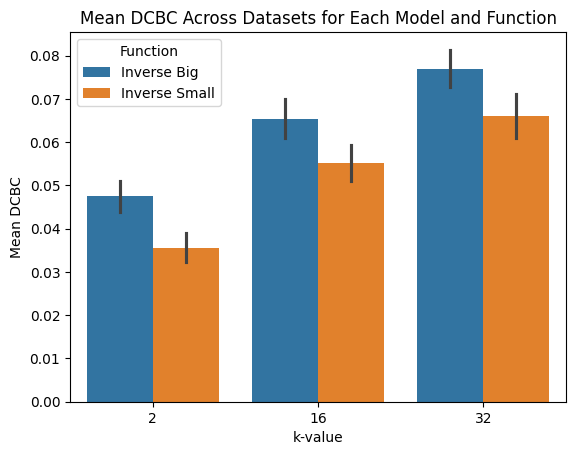

In [31]:
data = []

for k_index, k_value in enumerate(k_values):
    # For the Trace function
    # for dcbc_value in trace_dcbc[k_index]:
    #     # Convert to numpy if necessary
    #     if isinstance(dcbc_value, pt.Tensor):
    #         dcbc_value = dcbc_value.cpu().numpy()
    #     data.append({'k': k_value, 'DCBC': dcbc_value, 'Function': 'Trace'})
    
    # # For the Inverse Trace function
    # for dcbc_value in inverse_trace_dcbc[k_index]:
    #     if isinstance(dcbc_value, pt.Tensor):
    #         dcbc_value = dcbc_value.cpu().numpy()
    #     data.append({'k': k_value, 'DCBC': dcbc_value, 'Function': 'Inverse Trace'})
    
    # # For the Determinant function
    # for dcbc_value in determinant_dcbc[k_index]:
    #     if isinstance(dcbc_value, pt.Tensor):
    #         dcbc_value = dcbc_value.cpu().numpy()
    #     data.append({'k': k_value, 'DCBC': dcbc_value, 'Function': 'Determinant'})

    # # For the Maximize Lowest Eigenvalue function
    # for dcbc_value in maximize_lowest_eigenvalue_dcbc[k_index]:
    #     if isinstance(dcbc_value, pt.Tensor):
    #         dcbc_value = dcbc_value.cpu().numpy()
    #     data.append({'k': k_value, 'DCBC': dcbc_value, 'Function': 'Maximize Lowest Eigenvalue'})

    # # For the furthest tasks repeated battery
    # for dcbc_value in model_furthest_tasks_repeated_battery:
    #     if isinstance(dcbc_value, pt.Tensor):
    #         dcbc_value = dcbc_value.cpu().numpy()
    #     data.append({'k': k_value, 'DCBC': dcbc_value, 'Function': 'Furthest Tasks Repeated Battery'})

    # For the inverse combinations big
    for dcbc_value in inverse_combinations_big_dcbc[k_index]:
        if isinstance(dcbc_value, pt.Tensor):
            dcbc_value = dcbc_value.cpu().numpy()
        data.append({'k': k_value, 'DCBC': dcbc_value, 'Function': 'Inverse Big'})

    # For the inverse combinations small
    for dcbc_value in inverse_combinations_small_dcbc[k_index]:
        if isinstance(dcbc_value, pt.Tensor):
            dcbc_value = dcbc_value.cpu().numpy()
        data.append({'k': k_value, 'DCBC': dcbc_value, 'Function': 'Inverse Small'})
        

# Create a DataFrame from the data
df = pd.DataFrame(data)
df['DCBC']=df['DCBC'].astype(float)

# Ensure that k-values are treated as categorical variables
df['k'] = df['k'].astype('category')

# Create the bar plot with error bars representing the standard deviation across datasets
sns.barplot(x='k', y='DCBC', hue='Function', data=df, errorbar='sd')

# Customize the plot
plt.xlabel('k-value')
plt.ylabel('Mean DCBC')
plt.title('Mean DCBC Across Datasets for Each Model and Function')
plt.legend(title='Function')
plt.show()



In [33]:
def make_cov_matrix(data,info, condition_list):

        total_tasks = 29
        num_runs = 16

        cond_vec = np.tile(np.arange(1, total_tasks + 1), num_runs)
        part_vec = np.repeat(np.arange(1, num_runs + 1), total_tasks)

        num_subj = data.shape[0]
        G_matrices = []

        num_tasks = len(condition_list)

        ones_vector = np.ones((num_tasks, num_tasks))
        centering_matrix = np.eye(num_tasks) - ones_vector / num_tasks

        # remove nans
        data [np.isnan(data)] = 0
        for subj in range(num_subj): 
                G_s,E_s = est_G_crossval(data[subj], cond_vec, part_vec)
                G_matrices.append(G_s)
        G_matrices_stacked = np.stack(G_matrices, 0)
        G_group = np.nanmean(G_matrices_stacked, axis=0)


        #find indices of the cond_name = condition_list in the info
        indices = []
        for task in condition_list:
                task_index = info[info['cond_name'] == task].index.tolist()
                indices.append(task_index[0])


        G_group = G_group[indices][:,indices]

        #center the G matrix
        G_group_centered = centering_matrix @ G_group @ centering_matrix

        # get eigenvalues and plot spectrum
        # Compute the eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(G_group_centered)

        # Sort the eigenvalues (and corresponding eigenvectors) in descending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        sorted_eigenvalues = eigenvalues[sorted_indices]

        # exlcude last eigenvalue
        sorted_eigenvalues = sorted_eigenvalues[:-1]

        eig_vals = np.real(sorted_eigenvalues)

        return eig_vals

In [ ]:
info_mdtb_1

In [34]:
# Load data
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data,_  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
_,info  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')

data = data * ROI_mask

#remove nans
data[np.isnan(data)] = 0

In [35]:
variance_eigenvalue_lists = []
for battery in variance_combinations:
    print(battery)
    variance_eigenvalue_lists.append(make_cov_matrix(data,info,battery))

inverse_trace_eigenvalue_lists = []
for battery in inverse_combinations_big:
    print(battery)
    inverse_trace_eigenvalue_lists.append(make_cov_matrix(data,info,battery))

determinant_eigenvalue_lists = []
for battery in determinant_combinations:
    print(battery)
    determinant_eigenvalue_lists.append(make_cov_matrix(data,info,battery))

NameError: name 'variance_combinations' is not defined

In [32]:
# Define colors for each function
function_colors = {
    'Trace': 'blue',
    'Inverse Trace': 'green',
    'Determinant': 'red'
}

# Prepare the plot
plt.figure(figsize=(12, 8))

# Plot the eigenvalue spectrum for each battery in variance_combinations
for i, eigenvalues in enumerate(variance_eigenvalue_lists):
    plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, label=f'Variance Battery {i+1}', color=function_colors['Trace'])

# # Plot the eigenvalue spectrum for each battery in inverse_combinations
# for i, eigenvalues in enumerate(inverse_trace_eigenvalue_lists):
#     plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, label=f'Inverse Trace Battery {i+1}', color=function_colors['Inverse Trace'])

# Plot the eigenvalue spectrum for each battery in determinant_combinations
for i, eigenvalues in enumerate(determinant_eigenvalue_lists):
    plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, label=f'Determinant Battery {i+1}', color=function_colors['Determinant'])

# Customize the plot fig size
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue Magnitude')
plt.title('Eigenvalue Spectrum for Each Battery')
plt.legend()
plt.show()


NameError: name 'variance_eigenvalue_lists' is not defined

<Figure size 1200x800 with 0 Axes>

# Cos error eval

In [143]:
def perform_coserror_eval(model, data_train, data_eval, cond_v_train, part_v_train):
    sym_type = 'unsym'
    ar_model = model.arrange
    x_matrix = ut.indicator(cond_v_train)
    
    if sym_type == 'sym':
        K = ar_model.K_full
    else:
        K = ar_model.K

    print(K)
    
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_v_train,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_train])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)
    
    print(M_1.emissions[0].kappa)


    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    parcellation = [U_data]
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(parcellation, np.ndarray):
        parcellation = pt.tensor(parcellation, dtype=pt.get_default_dtype())

    eval_num_runs = 16
    eval_num_conds = 32

    #create cond_vec and part_vec for evaluation data
    cond_v_eval = np.tile(np.arange(1, eval_num_conds + 1), eval_num_runs)
    part_v_eval = np.repeat(np.arange(1, eval_num_runs + 1), eval_num_conds)
    #make into pt tensors
    part_v_eval = pt.tensor(part_v_eval, dtype=pt.long)

    x_matrix  = ut.indicator(cond_v_eval)

    if sym_type == 'sym':
        K = ar_model.K_full
    else:
        K = ar_model.K

    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_v_eval,
                            subject_specific_kappa=False, parcel_specific_kappa=False, 
                            subjects_equal_weight=True)
    
    M_eval = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_eval.initialize([data_eval])
    
    cosserror_indiv = calc_test_error(M_eval, data_eval, parcellation)
    return cosserror_indiv

In [ ]:
# Compute cosserror for all models
trace_coserror = []
inverse_trace_coserror = []
determinant_coserror = []

for model in models:
    trace_coserror.append(perform_coserror_eval(model, trace_dataset, data_mdtb_s2, cond_v_train, part_v_train))
    inverse_trace_coserror.append(perform_coserror_eval(model, inverse_trace_dataset, data_mdtb_s2, cond_v_train, part_v_train))
    determinant_coserror.append(perform_coserror_eval(model, determinant_dataset, data_mdtb_s2, cond_v_train, part_v_train))
    


In [ ]:
data = []

for k_index, k_value in enumerate(k_values):
    trace_subject_values = trace_coserror[k_index]
    for subject_value in trace_subject_values:
        data.append({'k': k_value, 'coserr': subject_value, 'Dataset': 'trace dataset'})

for k_index, k_value in enumerate(k_values):
    inverse_trace_subject_values = inverse_trace_coserror[k_index]
    for subject_value in inverse_trace_subject_values:
        data.append({'k': k_value, 'coserr': subject_value, 'Dataset': 'inverse trace dataset'})

for k_index, k_value in enumerate(k_values):
    determinant_subject_values = determinant_coserror[k_index]
    for subject_value in determinant_subject_values:
        data.append({'k': k_value, 'coserr': subject_value, 'Dataset': 'determinant dataset'})



# Create DataFrame for plotting
df = pd.DataFrame(data)
df = df.explode('coserr')


sns.barplot(x='k', y='coserr', hue='Dataset', data=df)

